## Project Title  
Impact of Festive Seasons on E-commerce Sales, Discounts, and Profitability  

---

## Business Problem  
E-commerce platforms experience significant fluctuations in sales during festive and non-festive periods. While festivals drive higher sales through aggressive discounting and promotional campaigns, they may also reduce profit margins and increase operational challenges such as product returns.  

This project aims to evaluate the true business impact of festive sales by analyzing revenue, discount strategies, and customer purchasing behavior to enable data-driven decision-making.  

---

##  Key Business Questions  

- Does the festive season drive higher-value purchases (Average Order Value)?  
- How do discount strategies impact revenue and profitability?  
- Do festivals increase operational risks such as product returns?  
- Which festivals generate the highest profit versus risk?  

---

## 📈 Key Metrics (KPIs)  

- Total Revenue  
- Profit (or Estimated Profit)  
- Average Order Value (AOV)  
- Discount Percentage  
- Return Rate  

---

##  Objectives  

1. Compare sales performance between festive and non-festive periods  
2. Analyze the relationship between discounts and profitability  
3. Identify top-performing product categories during festivals  
4. Evaluate customer behavior (orders, returns, spending patterns)  
5. Provide actionable business recommendations  

## Necessary Libraries & Modules 

In [1]:
#importing all the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("successfull imported")

successfull imported


#### <u>  Loading Data


In [2]:
# Load the dataset
df = pd.read_csv('ecommerce_Salesdataset.csv')

print("First 5 Rows Of The Dataset")
df.head(5).T

First 5 Rows Of The Dataset


,0,1,2,3,4
Order_ID,ORD100000,ORD100001,ORD100002,ORD100003,ORD100004
Order_Date,2024-04-12,2024-12-14,2024-09-27,2024-04-16,2024-03-12
Customer_ID,CUST4062,CUST9958,CUST4260,CUST1476,CUST3736
Customer_Segment,Regular,New,Premium,Regular,New
Product_Category,Beauty,Home Decor,Groceries,Fashion,Groceries
Units_Sold,5,5,2,5,5
Unit_Price,2020,9040,388,9614,5421
Revenue,9292.0,35256.0,760.48,37975.3,16534.05
Discount(%),8.0,22.0,2.0,21.0,39.0
Festival_Season,No,No,No,No,No


In [3]:
print("-> Dataset information:")

df.info()

print("-> Missing Value before preprocessing:")
df.isnull().sum()


-> Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             8000 non-null   object 
 1   Order_Date           8000 non-null   object 
 2   Customer_ID          8000 non-null   object 
 3   Customer_Segment     8000 non-null   object 
 4   Product_Category     8000 non-null   object 
 5   Units_Sold           8000 non-null   int64  
 6   Unit_Price           8000 non-null   int64  
 7   Revenue              8000 non-null   float64
 8   Discount(%)          7840 non-null   float64
 9   Festival_Season      8000 non-null   object 
 10  Festival_Name        1522 non-null   object 
 11  Payment_Method       7840 non-null   object 
 12  Delivery_Time(days)  8000 non-null   int64  
 13  Customer_Rating      7840 non-null   float64
 14  Returned             8000 non-null   object 
dtypes: float64(3),

Order_ID                  0
Order_Date                0
Customer_ID               0
Customer_Segment          0
Product_Category          0
Units_Sold                0
Unit_Price                0
Revenue                   0
Discount(%)             160
Festival_Season           0
Festival_Name          6478
Payment_Method          160
Delivery_Time(days)       0
Customer_Rating         160
Returned                  0
dtype: int64

- The Festival_Name column has approximately 75% null values. The majority of missing Festival_Name values are due to not being a festival (Actually, not missing values) instead of dropping Fill missing Festival_Name values only where Festival_Season is 'No' (or the value is null) with Non-Festival.
- Order_Date column needs to be converted into a proper date and time format.

In [47]:
#Statistical information of the dataset
print("Here are the Statistics of dataset")
df.describe().T


Here are the Statistics of dataset


,count,mean,min,25%,50%,75%,max,std
Order_Date,8000,2024-06-30 14:29:24,2024-01-01 00:00:00,2024-04-02 00:00:00,2024-06-29 00:00:00,2024-09-30 00:00:00,2024-12-31 00:00:00,NaN
Units_Sold,8000.0,3.056875,1.0,2.0,3.0,4.0,5.0,1.420877
Unit_Price,8000.0,5125.13075,200.0,2656.0,5114.0,7606.25,9997.0,2836.248727
Revenue,8000.0,11811.398488,133.56,4311.48,9190.615,17054.07,48970.35,9527.269143
Discount(%),8000.0,24.46325,0.0,12.0,25.0,37.0,49.0,14.286984
Delivery_Time(days),8000.0,4.0015,1.0,2.0,4.0,6.0,7.0,1.994303
Customer_Rating,8000.0,3.761813,2.5,3.2,3.8,4.4,5.0,0.710576
Sales,8000.0,9249.181091,70.7868,3050.137375,6695.7176,12932.264,48480.6465,8327.04923


In [4]:
#Applying a lambda function to impute the Festival_Name columns optimally
df['Festival_Name'] = df['Festival_Name'].fillna(
    df.apply(lambda row: 'Non-Festival' if row['Festival_Season'] == 'No' else row['Festival_Name'], axis=1)
)

In [5]:
# Impute Discount(%) and Customer_Rating with their respective medians

df['Discount(%)'] = df['Discount(%)'].fillna(df['Discount(%)'].median())
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].median())

In [6]:
# Converts Order_Date to datetime format for clean analysis

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [7]:
# Handle true missing data (dropna only for essential columns)
critical_cols = ['Units_Sold', 'Unit_Price', 'Revenue', 'Discount(%)', 'Delivery_Time(days)', 'Customer_Rating']
df_cleaned = df.dropna(subset=critical_cols).copy()

In [8]:
# Calculate the 'Sales' column
# Sales = Revenue * (1 - Discount(%) / 100)
df_cleaned['Sales'] = df_cleaned['Revenue'] * (1 - df_cleaned['Discount(%)'] / 100)

In [9]:
# Checking the new size 
print(f"Original rows: {len(df)}")
print(f"Rows after optimal cleaning: {len(df_cleaned)}")
print("\nFirst 5 rows of the optimally cleaned data:")
df_cleaned.head().T

Original rows: 8000
Rows after optimal cleaning: 8000

First 5 rows of the optimally cleaned data:


,0,1,2,3,4
Order_ID,ORD100000,ORD100001,ORD100002,ORD100003,ORD100004
Order_Date,2024-04-12 00:00:00,2024-12-14 00:00:00,2024-09-27 00:00:00,2024-04-16 00:00:00,2024-03-12 00:00:00
Customer_ID,CUST4062,CUST9958,CUST4260,CUST1476,CUST3736
Customer_Segment,Regular,New,Premium,Regular,New
Product_Category,Beauty,Home Decor,Groceries,Fashion,Groceries
Units_Sold,5,5,2,5,5
Unit_Price,2020,9040,388,9614,5421
Revenue,9292.0,35256.0,760.48,37975.3,16534.05
Discount(%),8.0,22.0,2.0,21.0,39.0
Festival_Season,No,No,No,No,No


## Store Data in SQL

In [10]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")

df_cleaned.to_sql("sales_data", conn, if_exists="replace", index=False)

8000

Data is stored in a relational database to simulate real-world data environments.

##  SQL-Based Data Analysis  

To simulate real-world data workflows, the cleaned dataset is stored in a relational database and queried using SQL for aggregation and business insights.

## Query 1: Festival vs Non-Festival

In [11]:
query1 = """
SELECT 
    Festival_Season,
    AVG(Revenue) AS avg_revenue,
    AVG("Discount(%)") AS avg_discount,
    AVG(CASE WHEN Returned = 'Yes' THEN 1 ELSE 0 END) AS return_rate
FROM sales_data
GROUP BY Festival_Season;
"""

result1 = pd.read_sql(query1, conn)
result1

,Festival_Season,avg_revenue,avg_discount,return_rate
0,No,11753.187130,24.639182,0.097644
1,Yes,12054.021021,23.729974,0.104005


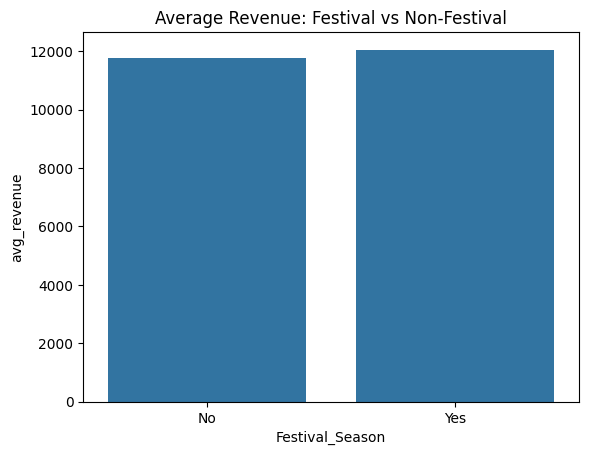

In [12]:
sns.barplot(x='Festival_Season', y='avg_revenue', data=result1)
plt.title("Average Revenue: Festival vs Non-Festival")
plt.show()

Insight:


Festival periods show higher average revenue, indicating increased customer spending. However, the return rate is also elevated, suggesting a potential trade-off between sales growth and operational costs.

## Query 2: Top Categories During Festivals

In [13]:
query2 = """
SELECT 
    Product_Category,
    SUM(Revenue) AS total_revenue
FROM sales_data
WHERE Festival_Season = 'Yes'
GROUP BY Product_Category
ORDER BY total_revenue DESC;
"""

result2 = pd.read_sql(query2, conn)
result2

,Product_Category,total_revenue
0,Electronics,3967657.18
1,Home Decor,3838874.23
2,Fashion,3724878.30
3,Groceries,3630288.32
4,Beauty,3497926.51


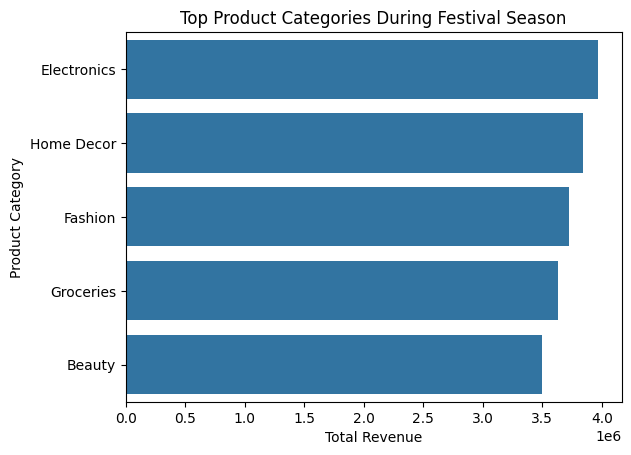

In [14]:
plt.figure()
sns.barplot(x='total_revenue', y='Product_Category', data=result2)
plt.title("Top Product Categories During Festival Season")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.show()

Insight:

Certain categories dominate festive sales, suggesting targeted inventory and marketing strategies can maximize revenue.

## Query 3: Discount vs Revenue

In [15]:
query3 = """
SELECT 
    ROUND("Discount(%)", 0) AS discount_bucket,
    AVG(Revenue) AS avg_revenue
FROM sales_data
GROUP BY discount_bucket
ORDER BY discount_bucket;
"""

result3 = pd.read_sql(query3, conn)
result3

,discount_bucket,avg_revenue
0,0.0,15357.190184
1,1.0,17117.496000
2,2.0,15867.213988
3,3.0,15284.657931
4,4.0,14900.866667
5,5.0,13714.569799
6,6.0,13203.390641
7,7.0,14585.657657
8,8.0,14644.453333
9,9.0,15051.992968


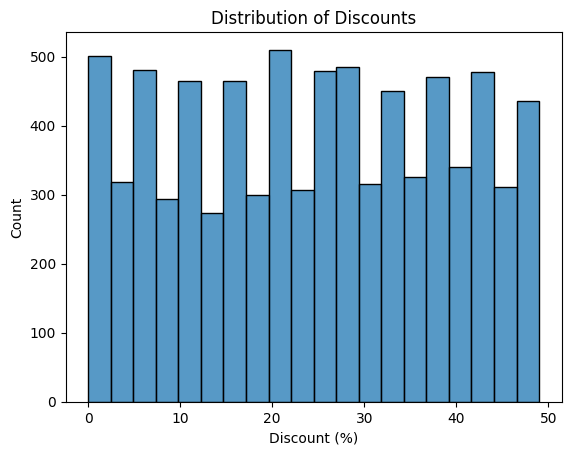

In [16]:
plt.figure()
sns.histplot(df['Discount(%)'], bins=20)
plt.title("Distribution of Discounts")
plt.xlabel("Discount (%)")
plt.show()

Insight:

Most discounts fall within a specific range, indicating standardized pricing strategies.

<b>Business Recommendation:</b>

Instead of offering very high discounts, companies should identify an optimal discount range that maximizes revenue without significantly impacting margins.

#### <u> Comparative Analysis: Festival vs. Non-Festival Season

In [18]:
# Group data by Festival_Season to compare key performance metrics
festival_impact = df_cleaned.groupby('Festival_Season').agg(
    Total_Sales=('Sales', 'sum'),
    Average_Sales_Per_Order=('Sales', 'mean'),
    Average_Discount_Percent=('Discount(%)', 'mean'),
    Total_Orders=('Order_ID', 'count'),
    Total_Returned=('Returned', lambda x: (x == 'Yes').sum())
).reset_index()

# Calculating the critical Return Rate (%)
festival_impact['Return_Rate_Percent'] = (festival_impact['Total_Returned'] / festival_impact['Total_Orders']) * 100

# Prepare data columns for clean visualization
festival_impact['Total_Sales_Millions'] = festival_impact['Total_Sales'] / 1000000
festival_impact['Average_Sales_Per_Order'] = festival_impact['Average_Sales_Per_Order'].round(0)
festival_impact['Return_Rate_Percent'] = festival_impact['Return_Rate_Percent'].round(2)


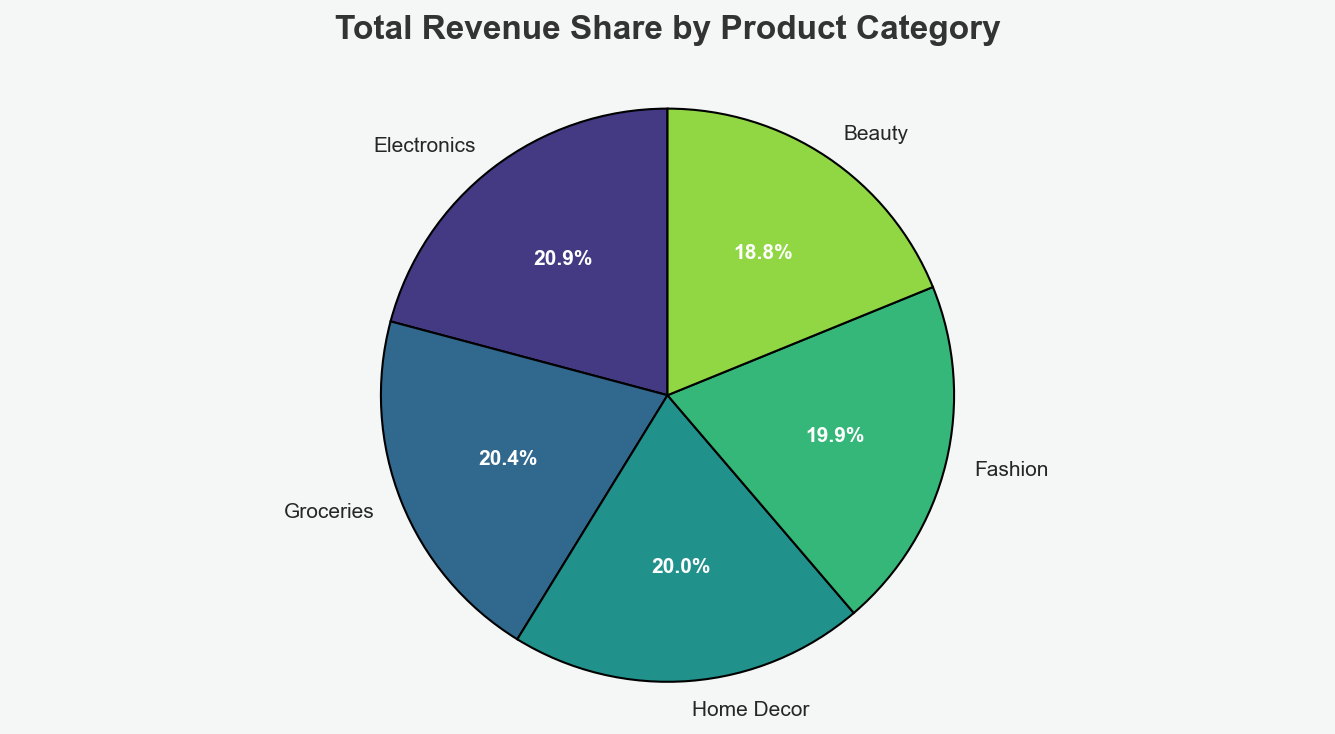

In [45]:
#Data Aggregation: Calculate Total Sales by Product Category 

# Group by category and sum the final sales
revenue_share = df.groupby('Product_Category')['Sales'].sum().reset_index()

# Calculate the percentage share
total_sales = revenue_share['Sales'].sum()
revenue_share['Share_Percent'] = (revenue_share['Sales'] / total_sales) * 100

# Sort the data for better visualization
revenue_share = revenue_share.sort_values(by='Share_Percent', ascending=False)

# Visualization: Revenue Share Pie Chart 

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150 
plt.figure(figsize=(9, 5), facecolor='#f4f7f6')

# Define a palette with a contrasting color for the largest slice
# Using a bright palette that clearly distinguishes categories
colors = sns.color_palette('viridis', len(revenue_share))
# If Groceries is the top, make it stand out with a specific color 
if revenue_share.iloc[0]['Product_Category'] == 'Groceries':
    colors[0] = '#FFC300' 

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    revenue_share['Share_Percent'],
    labels=revenue_share['Product_Category'],
    autopct='%1.1f%%',         # Format for percentages
    startangle=90,             # Start the first slice at the top
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1} # Add borders for clarity
)

# Customize percentage text for better readability
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

# --- Chart Aesthetics ---
plt.title(
    'Total Revenue Share by Product Category', 
    fontsize=16, 
    fontweight='bold', 
    color='#333333',
    pad=20
)

# Ensure the pie chart is a circle
plt.axis('equal') 

plt.tight_layout()
plt.show()
plt.close()

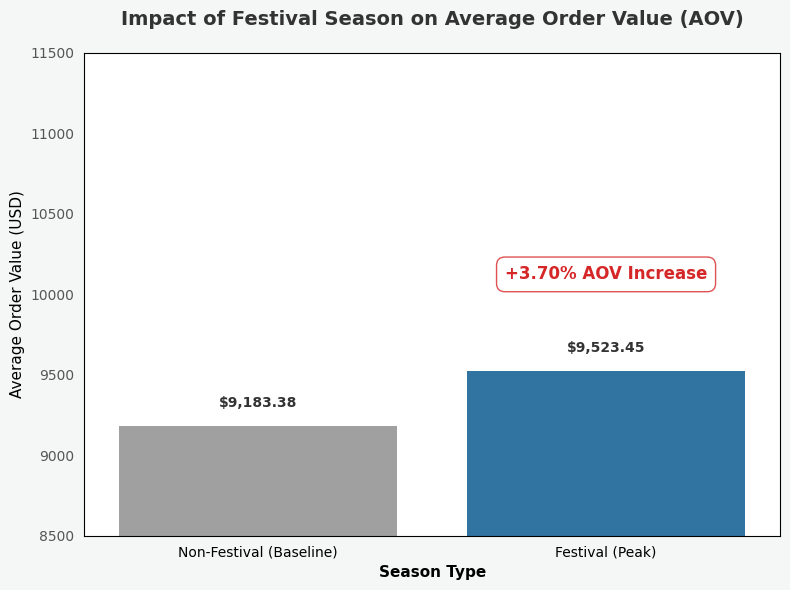

In [19]:
# Calculating AOV (Average Order Value)

aov_comparison = df_cleaned.groupby('Festival_Season').agg(
    Average_Order_Value=('Sales', 'mean')
).reset_index()

# Calculate the percentage difference for annotation
aov_no = aov_comparison[aov_comparison['Festival_Season'] == 'No']['Average_Order_Value'].iloc[0]
aov_yes = aov_comparison[aov_comparison['Festival_Season'] == 'Yes']['Average_Order_Value'].iloc[0]
percent_increase = ((aov_yes - aov_no) / aov_no) * 100

# Set the explicit order for the x-axis
category_order = ['No', 'Yes']

# Visualization: AOV Comparison Chart 
plt.figure(figsize=(8, 6), facecolor='#f4f7f6') # Light gray background for figure

# Custom Color Palette: Blue/Gray for baseline, Vibrant Gold for focus
custom_palette = {'No': '#a0a0a0', 'Yes': '#1f77b4'} # Gray and Gold

ax = plt.gca() # Get current axes

bar = sns.barplot(
    data=aov_comparison,
    x='Festival_Season',
    y='Average_Order_Value',
    hue='Festival_Season',
    order=category_order,
    palette=custom_palette,
)

# Remove the legend
if ax.get_legend():
    ax.legend_.remove()

# Title and Labels
plt.title(
    'Impact of Festival Season on Average Order Value (AOV)', 
    fontsize=14, 
    fontweight='bold', 
    color='#333333',
    pad=20
)
plt.xlabel('Season Type', fontsize=11, fontweight='semibold')
plt.ylabel('Average Order Value (USD)', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Non-Festival (Baseline)', 'Festival (Peak)'], fontsize=10)

# Customize the Y-axis ticks for better look
plt.tick_params(axis='y', which='both', left=False, labelleft=True, colors='#555555')
plt.tick_params(axis='x', which='both', bottom=False)

# Add data labels formatted as currency and bold
for i, container in enumerate(bar.containers):
    # Get the height of the bar
    height = container.patches[0].get_height()
    # Add annotation slightly above the bar
    ax.text(
        i, height + 100, 
        f'${height:,.2f}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold', 
        color='#333333'
    )
    
ax.text(
    1, aov_yes + 600, 
    f'+{percent_increase:.2f}% AOV Increase', 
    ha='center', 
    va='center', 
    fontsize=12, 
    color='#d62728', # Red for impact
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8, ec="#d62728")
)
# Set y-limit to zoom in and emphasize the difference
plt.ylim(8500, 11500)
plt.tight_layout()
plt.show()
plt.close()

###  Insight  

AOV increased by 3.70% during festivals, indicating that customers tend to spend more per transaction during promotional events.  

###  Business Implication  

This suggests strong upselling opportunities during festivals.  

###  Recommendation  

E-commerce platforms should introduce product bundles and cross-selling strategies to maximize revenue per customer during high-demand periods.

#### <u> Specific Festival Analysis

In [20]:
# Filter for festival orders and group by specific Festival_Name
festival_sales_name = df_cleaned[df_cleaned['Festival_Season'] == 'Yes'].groupby('Festival_Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Orders=('Order_ID', 'count'),
    Return_Rate_Percent=('Returned', lambda x: (x == 'Yes').sum() / len(x) * 100)
).reset_index()

# Prepare data for clean visualization and sorting
festival_sales_name['Total_Sales_Millions'] = (festival_sales_name['Total_Sales'] / 1000000)
festival_sales_name['Return_Rate_Percent'] = festival_sales_name['Return_Rate_Percent'].round(2)
festival_sales_name_sorted = festival_sales_name.sort_values(by='Total_Sales_Millions', ascending=False)
festival_sales_name_sorted_returns = festival_sales_name.sort_values(by='Return_Rate_Percent', ascending=False)

#### <u> Correlation Matrix

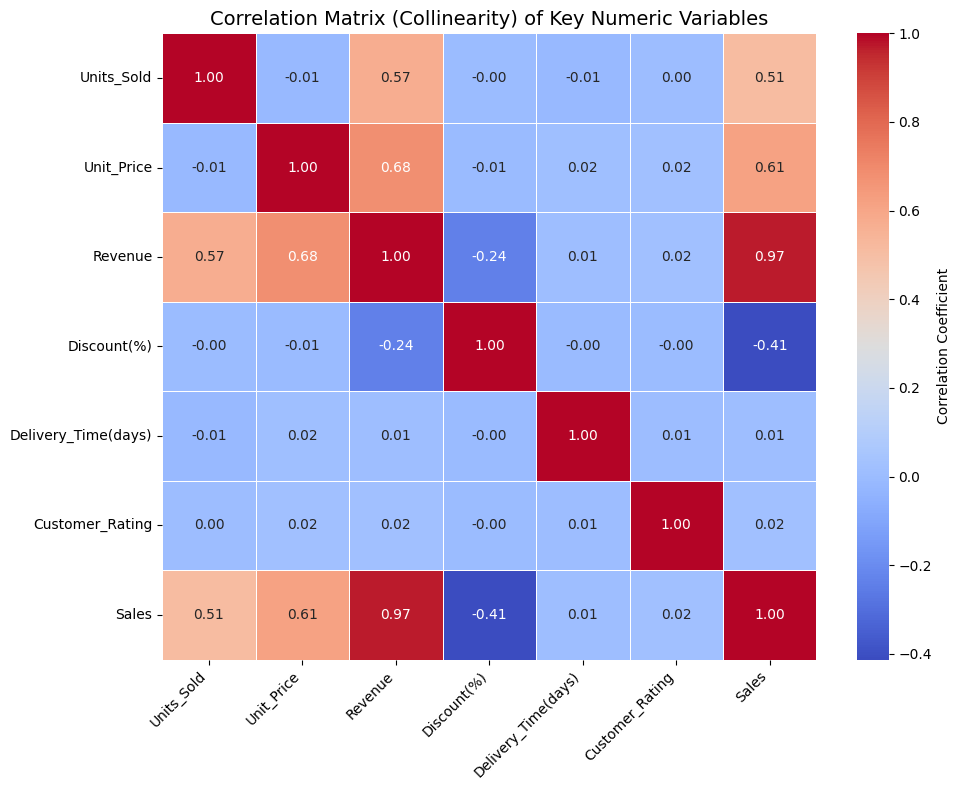

In [21]:
 # Select numeric columns for the correlation matrix
numeric_cols = ['Units_Sold', 'Unit_Price', 'Revenue', 'Discount(%)', 'Delivery_Time(days)', 'Customer_Rating', 'Sales']
df_corr = df_cleaned[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix (Collinearity) of Key Numeric Variables', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### (Correlation Heatmap) -
The heatmap above shows the correlation coefficients between key numeric variables. This helps in identifying drivers of <b> Revenue and Sales.</b>

 - **Revenue vs. Sales (0.97)	High Positive:** This is expected, as sales are derived directly from revenue. A strong correlation confirms the calculated 'Sales' metric is reliable.

 - **Unit_Price vs. Revenue	(0.68)	Strong Positive:** As the unit price increases, the total revenue of the order strongly increases. This confirms that selling higher-priced items is the primary way to boost revenue.
 
- **Unit_Price vs. Sales	(0.61)	Strong Positive:** Higher unit price leads to higher final sales value, making Unit Price the most important metric for driving high AOV, especially during the festival season.

- **Units_Sold vs. Revenue	(0.57)	Moderate Positive:** Selling more units helps revenue, but not as significantly as increasing the unit price.

- **Discount(%) vs. Sales	(-0.42) Not dominant:** As the Discount Percentage decreases (you offer a smaller discount), the final Sales value increases.

#### <u> Data Visualization of Festival Insights

In [22]:
# Set a consistent style for charts
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150 # Higher resolution for better image quality

#### <u> BAR CHART - Total Sales Comparison 

<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Welcome\AppData\Local\Temp\ipykernel_26776\1534950611.py:6: SyntaxWarning: invalid escape sequence '\$'
  bar1.bar_label(bar1.containers[0], fmt='\$%.2fM')
C:\Users\Welcome\AppData\Local\Temp\ipykernel_26776\1534950611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar1 = sns.barplot(


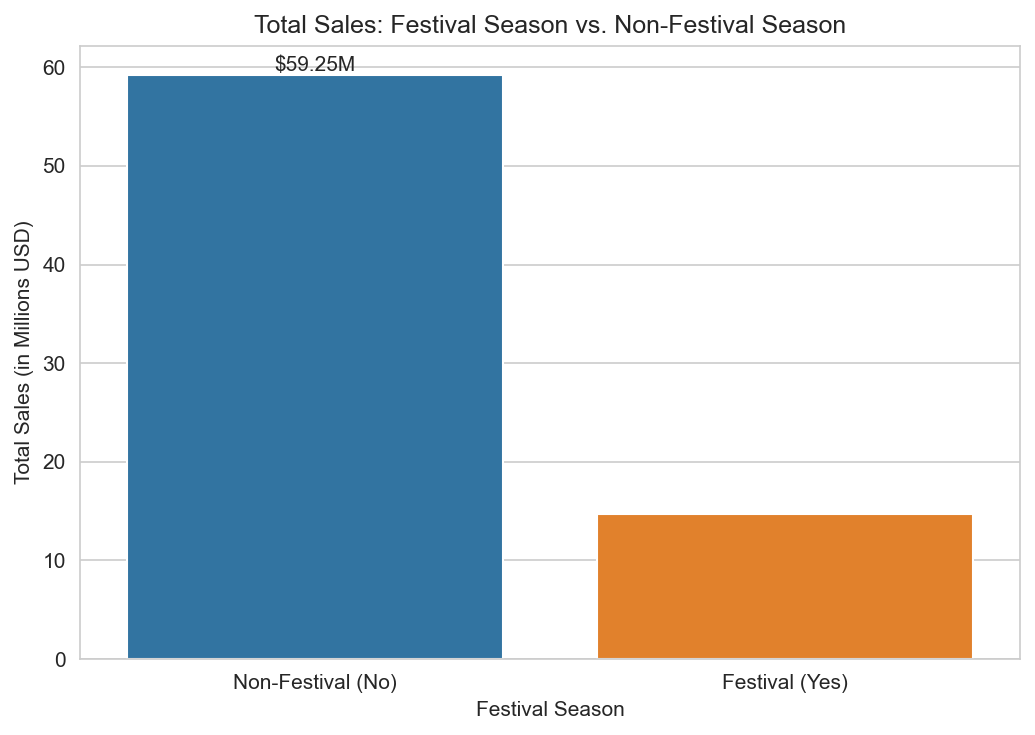

In [23]:
# Chart 1: Total Sales Comparison 
plt.figure(figsize=(7, 5))
bar1 = sns.barplot(
    data=festival_impact, x='Festival_Season', y='Total_Sales_Millions', palette=['#1f77b4', '#ff7f0e']
)
bar1.bar_label(bar1.containers[0], fmt='\$%.2fM')
plt.title('Total Sales: Festival Season vs. Non-Festival Season', fontsize=12)
plt.xlabel('Festival Season', fontsize=10)
plt.ylabel('Total Sales (in Millions USD)', fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Non-Festival (No)', 'Festival (Yes)'])
plt.tight_layout()
plt.show()
plt.close()

#### <u> BAR CHART - Return Rate Comparison 

C:\Users\Welcome\AppData\Local\Temp\ipykernel_26776\773946806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar2 = sns.barplot(


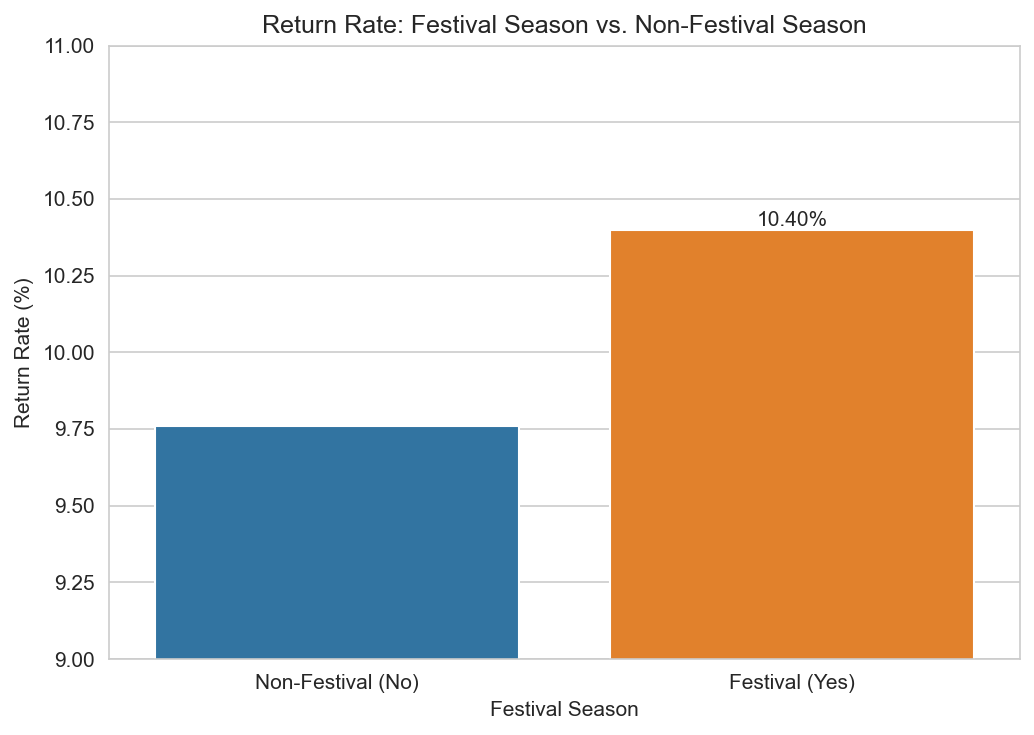

In [42]:
# Chart 2- Return Rate Comparison 
plt.figure(figsize=(7, 5))
bar2 = sns.barplot(
    data=festival_impact, x='Festival_Season', y='Return_Rate_Percent', palette=['#1f77b4', '#ff7f0e']
)
bar2.bar_label(bar2.containers[1], fmt='%.2f%%')
plt.title('Return Rate: Festival Season vs. Non-Festival Season', fontsize=12)
plt.xlabel('Festival Season', fontsize=10)
plt.ylabel('Return Rate (%)', fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Non-Festival (No)', 'Festival (Yes)'])
plt.ylim(9.0, 11.0)
plt.tight_layout()
plt.show()
plt.close()

###  Insight  

Return rates tend to increase by 10.40% during festival periods, likely due to impulsive buying behavior driven by discounts and promotions.  

###  Business Implication  

Higher return rates can increase operational costs and reduce overall profitability.  

###  Recommendation  

Improve product descriptions, customer reviews, and sizing accuracy to reduce return rates during high-volume festive sales.

#### <u> BAR CHART : Total Sales by Specific Festival (Problematic Chart)

<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Welcome\AppData\Local\Temp\ipykernel_26776\3337076105.py:7: SyntaxWarning: invalid escape sequence '\$'
  bar3.bar_label(bar3.containers[0], fmt='\$%.2fM')
C:\Users\Welcome\AppData\Local\Temp\ipykernel_26776\3337076105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar3 = sns.barplot(


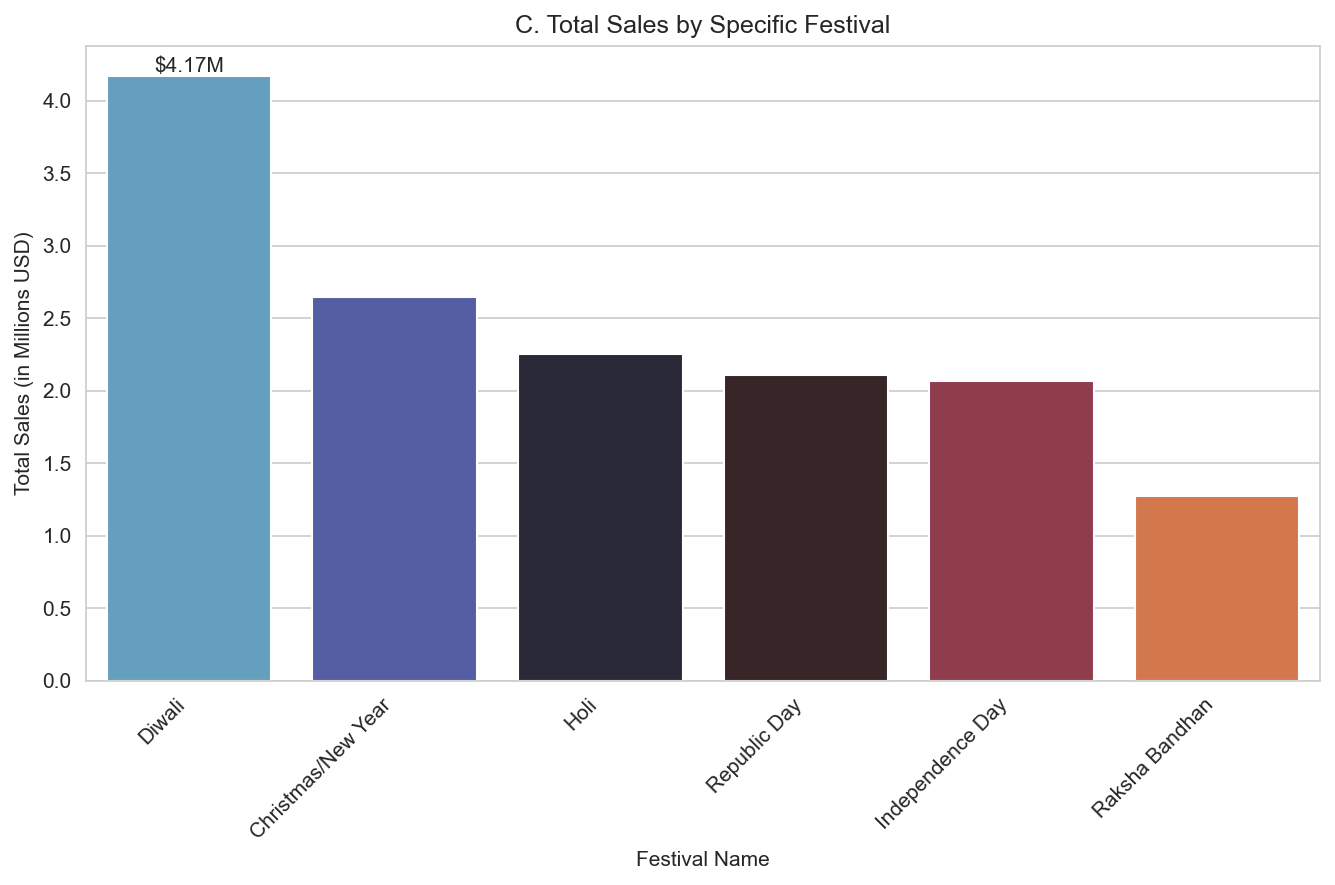

In [41]:
# Chart: Sales by Specific Festival (Bar Chart)
plt.figure(figsize=(9, 6))
bar3 = sns.barplot(
    data=festival_sales_name_sorted, x='Festival_Name', y='Total_Sales_Millions',
    palette=sns.color_palette("icefire", len(festival_sales_name_sorted))
)
bar3.bar_label(bar3.containers[0], fmt='\$%.2fM')
plt.title('C. Total Sales by Specific Festival', fontsize=12)
plt.xlabel('Festival Name', fontsize=10)
plt.ylabel('Total Sales (in Millions USD)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()


###  Insight  

Sales performance varies significantly across different festivals, indicating that not all festive events contribute equally to revenue generation.  

###  Business Implication  

Some festivals provide higher returns on investment, while others may not justify aggressive promotions.  

###  Recommendation  

Companies should prioritize high-performing festivals for marketing and inventory allocation while optimizing budgets for lower-performing events.

#### <u> BAR CHART -  Return Rate by Specific Festival

C:\Users\Welcome\AppData\Local\Temp\ipykernel_26776\3812551655.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar4 = sns.barplot(


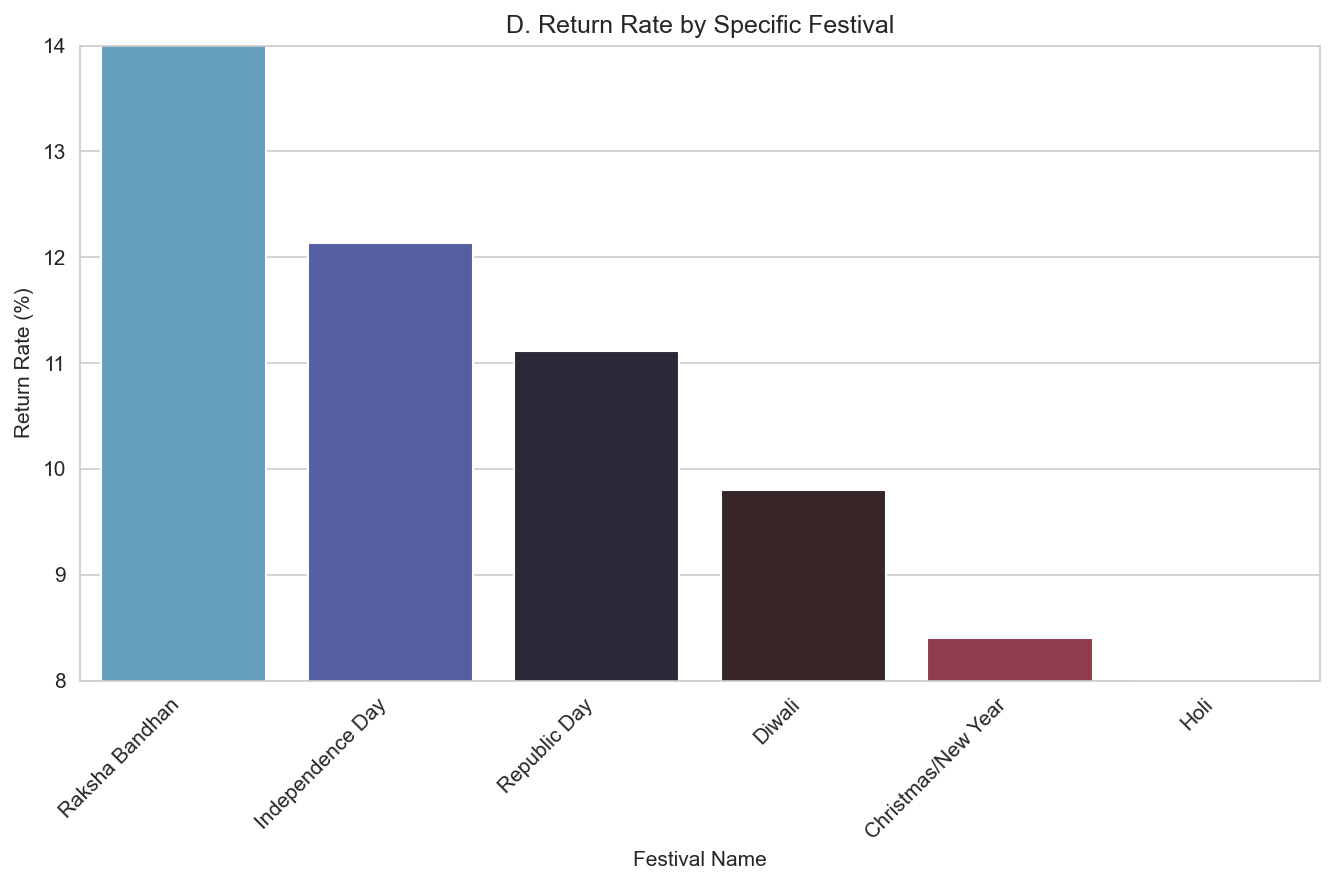

In [26]:
# Chart 4: Return Rate by Specific Festival
plt.figure(figsize=(9, 6))
festival_sales_name_sorted_returns = festival_sales_name.sort_values(by='Return_Rate_Percent', ascending=False)
bar4 = sns.barplot(
    data=festival_sales_name_sorted_returns, x='Festival_Name', y='Return_Rate_Percent',
    palette=sns.color_palette("icefire", len(festival_sales_name_sorted_returns))
)
bar4.bar_label(bar4.containers[0], fmt='%.2f%%')
plt.title('D. Return Rate by Specific Festival', fontsize=12)
plt.xlabel('Festival Name', fontsize=10)
plt.ylabel('Return Rate (%)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.ylim(8.0, 14.0)
plt.tight_layout()
plt.show()
plt.close()

#### <u> Dual-Axis Chart (Sales vs. Return Rate by Festival) - Risk/Reward View

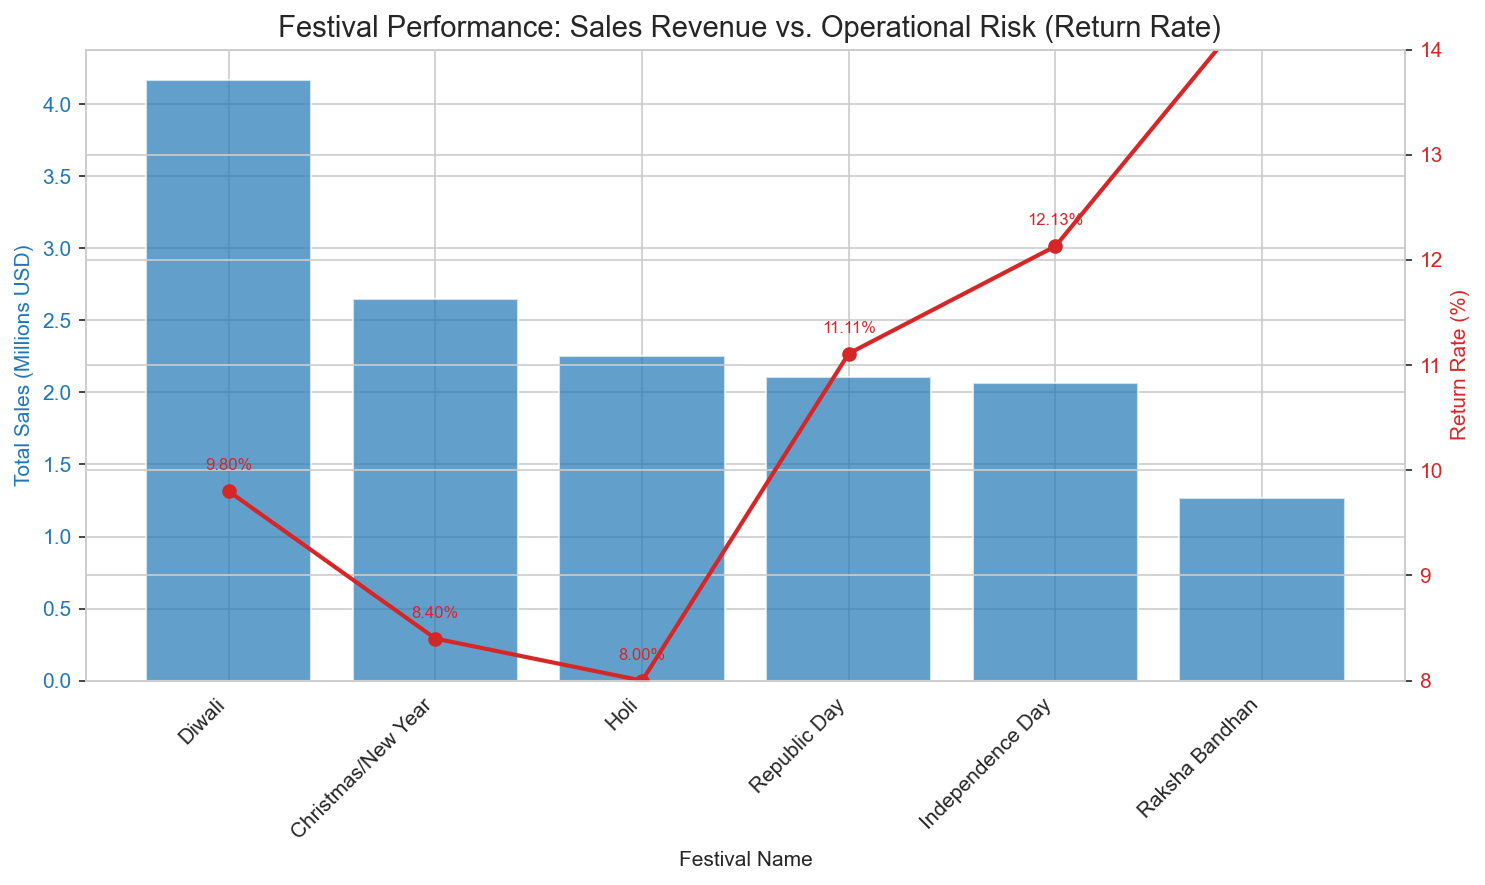

In [27]:
# Chart 5: Dual-Axis Chart (Sales vs. Return Rate by Festival) - Risk/Reward View
fig, ax1 = plt.subplots(figsize=(10, 6))
color1 = '#1f77b4' # blue for Sales
bars = ax1.bar(
    festival_sales_name_sorted['Festival_Name'], festival_sales_name_sorted['Total_Sales_Millions'],
    color=color1, alpha=0.7, label='Total Sales (Millions)'
)
ax1.set_xlabel('Festival Name', fontsize=10)
ax1.set_ylabel('Total Sales (Millions USD)', color=color1, fontsize=10)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.get_xticklabels(), ha='right')

ax2 = ax1.twinx()
color2 = '#d62728' # red for Return Rate
ax2.plot(
    festival_sales_name_sorted['Festival_Name'], festival_sales_name_sorted['Return_Rate_Percent'],
    color=color2, marker='o', linestyle='-', linewidth=2, label='Return Rate (%)'
)
ax2.set_ylabel('Return Rate (%)', color=color2, fontsize=10)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(8, 14)
for x, y in zip(festival_sales_name_sorted['Festival_Name'], festival_sales_name_sorted['Return_Rate_Percent']):
    ax2.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', color=color2, fontsize=8)

plt.title(' Festival Performance: Sales Revenue vs. Operational Risk (Return Rate)', fontsize=14)
fig.tight_layout()
plt.show()
plt.close()

#### <u> Scatter Plot with Regression Line (Unit Price vs. Sales) - Collinearity Visualization

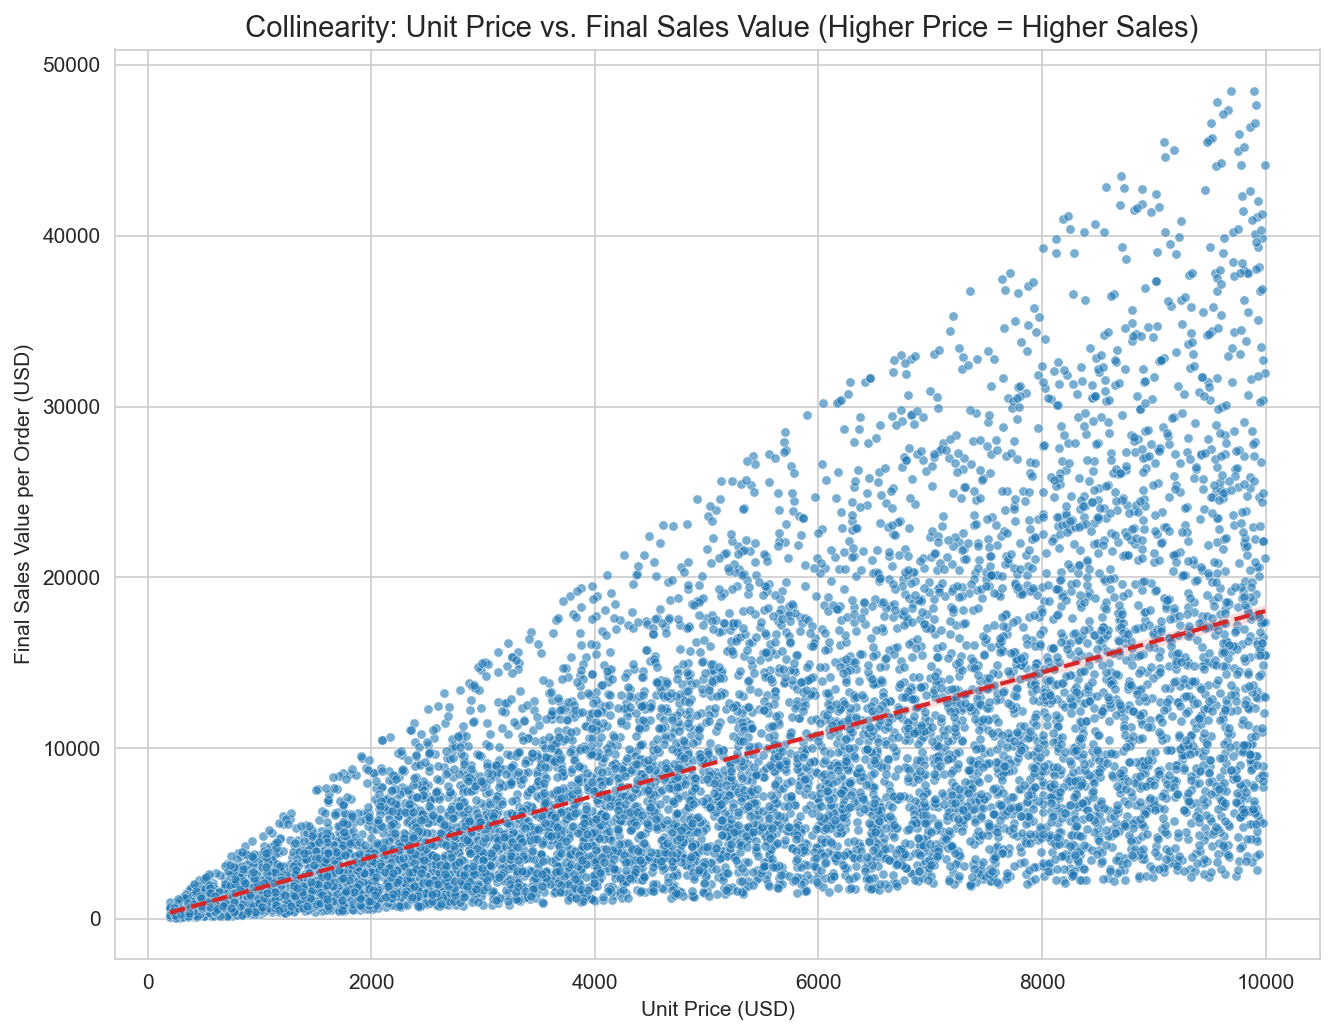

In [43]:
# Chart 6: Scatter Plot with Regression Line (Unit Price vs. Sales) - Collinearity Visualization
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_cleaned, x='Unit_Price', y='Sales', alpha=0.6, s=20, color='#1f77b4' # green
)
sns.regplot(
    data=df_cleaned, x='Unit_Price', y='Sales', scatter=False, color='#d62728', # red
    line_kws={'linewidth': 2, 'linestyle': '--'}
)
plt.title(' Collinearity: Unit Price vs. Final Sales Value (Higher Price = Higher Sales)', fontsize=14)
plt.xlabel('Unit Price (USD)', fontsize=10)
plt.ylabel('Final Sales Value per Order (USD)', fontsize=10)
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()
plt.close()



###  Key Business Insights & Recommendations  

1. **Festival Seasons Drive Higher Revenue but Increase Risk**  
   - While average revenue and AOV increases by 3.70% during festivals, return rates also rise by 10.40%.  
   - Recommendation: Optimize return policies and improve product descriptions during festivals to reduce return rates.  

2. **Discount Strategy Needs Optimization**  
   - Higher discounts do not always result in proportional revenue growth.  
   - Recommendation: Identify optimal discount range instead of aggressive discounting to protect margins.  

3. **Category-Level Targeting is Crucial**  
   - Certain product categories dominate festive sales.  
   - Recommendation: Focus marketing spend and inventory on high-performing categories.  

4. **Customer Behavior Changes During Festivals**  
   - Customers tend to spend more per order (higher AOV).  
   - Recommendation: Use bundling and upselling strategies to maximize revenue per transaction.  

5. **Operational Planning Required for Festivals**  
   - Increased order volume and returns create operational pressure.  
   - Recommendation: Strengthen logistics and inventory planning before major festivals.  

#### <u> Applying Machine Learning

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score


#### <u> Defining the Target Variable

In [30]:
# Calculate the Target Variable: Final Sales Value
df['Sales'] = df['Revenue'] * (1 - df['Discount(%)'] / 100)# Defining Features and Target 

# X: Features (Inputs to the model)
# Y: Target (What we want to predict)
X = df.drop(columns=['Sales', 'Order_ID', 'Order_Date', 'Customer_ID', 'Revenue'])
y = df['Sales']

In [31]:
# Identify categorical and numerical features for preprocessing
categorical_features = [
    'Customer_Segment', 'Product_Category', 'Festival_Season', 
    'Festival_Name', 'Payment_Method', 'Returned'
]
numerical_features = [
    'Units_Sold', 'Unit_Price', 'Discount(%)', 
    'Delivery_Time(days)', 'Customer_Rating'
]

#### <u>  Preprocessing Pipeline 

In [32]:
# Creating a preprocessing object using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop' # Drop any other columns not specified
)

#### <u> Model Training and Evaluation Pipeline

In [33]:
 

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
# Creating the full pipeline: Preprocessing -> Model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10))
])

In [35]:
# Train the model
print("Training Random Forest Regressor")
rf_pipeline.fit(X_train, y_train)
print("Training complete")

Training Random Forest Regressor
Training complete


#### <u> Model prediction

In [36]:
# Make predictions on the test set
y_pred = rf_pipeline.predict(X_test)

# Evaluate the model performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f} (Avg. error margin)")
print(f"R-squared (R2) Score: {r2:.4f} (Variance explained)")


Model Evaluation:
Mean Absolute Error (MAE): $251.87 (Avg. error margin)
R-squared (R2) Score: 0.9972 (Variance explained)



The model was evaluated on the test set, and its performance is summarised below:

**Mean Absolute Error (MAE): $251.87**

- This indicates that, on average, the model's predictions are off from the actual profit by approximately $251.84


**R-squared (R2 Score): 0.936**

- An R2 of 0.9972 means that the model can explain about 99.7% of the variance in the Profit data, which suggests a strong fit.

#### <u> Feature Importance Extraction

C:\Users\Welcome\AppData\Local\Temp\ipykernel_26776\3660312650.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


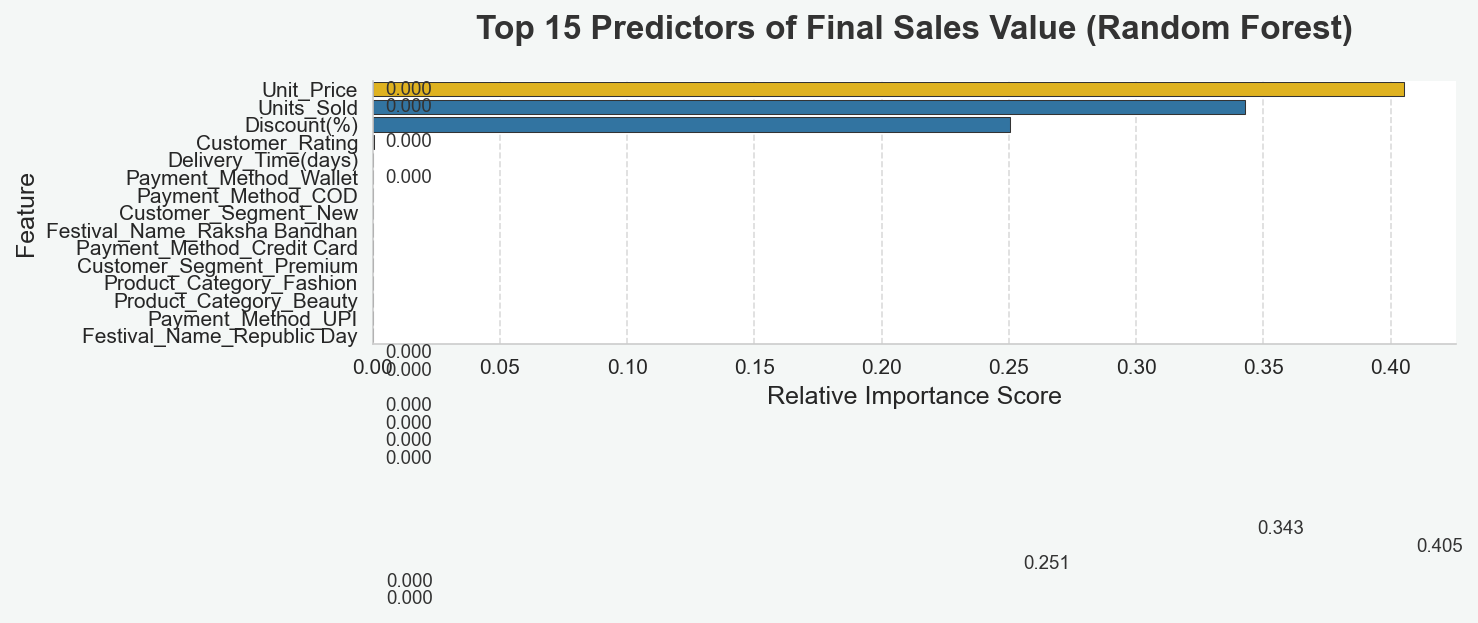

In [37]:
# Feature Importance Extraction

# Get all feature names after encoding
encoded_feature_names = (
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)
all_feature_names = np.concatenate([encoded_feature_names, numerical_features])

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_pipeline.named_steps['regressor'].feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select the top 15 features
top_n = 15
top_importance = importance_df.head(top_n).copy()

#visualizing the top Features
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150 
plt.figure(figsize=(10, 10), facecolor='#f4f7f6')

# Define custom colors: Gold for the top driver, Blue for others
colors = ['#FFC300' if i == 0 else '#1f77b4' for i in range(top_n)]

# Create the horizontal bar plot
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_importance,
    palette=colors,
    edgecolor='#333333',
    linewidth=0.5,
    orient='h'
)

# --- Chart Aesthetics ---
plt.title(
    f'Top {top_n} Predictors of Final Sales Value (Random Forest)', 
    fontsize=16, 
    fontweight='bold', 
    color='#333333',
    pad=20
)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Add value labels to the bars
for index, row in top_importance.iterrows():
    plt.text(
        row['Importance'] + 0.005, 
        index, 
        f'{row["Importance"]:.3f}', 
        va='center', 
        fontsize=9,
        color='#333333'
    )

# Clean up axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().xaxis.grid(True, linestyle='--', alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.tight_layout()
plt.show()
plt.close()

#### <u> Display the top 15 most important features

In [38]:

print("\n--- Top 15 Feature Importances for Final Sales Value ---")
print(importance_df.head(15).to_markdown(index=False, numalign="left", stralign="left"))


--- Top 15 Feature Importances for Final Sales Value ---
| Feature                      | Importance   |
|:-----------------------------|:-------------|
| Unit_Price                   | 0.40525      |
| Units_Sold                   | 0.342725     |
| Discount(%)                  | 0.250574     |
| Customer_Rating              | 0.000398519  |
| Delivery_Time(days)          | 0.000195997  |
| Payment_Method_Wallet        | 9.17489e-05  |
| Payment_Method_COD           | 6.79204e-05  |
| Customer_Segment_New         | 6.27865e-05  |
| Festival_Name_Raksha Bandhan | 5.29343e-05  |
| Payment_Method_Credit Card   | 4.50376e-05  |
| Customer_Segment_Premium     | 4.50213e-05  |
| Product_Category_Fashion     | 4.41933e-05  |
| Product_Category_Beauty      | 4.41567e-05  |
| Payment_Method_UPI           | 4.34702e-05  |
| Festival_Name_Republic Day   | 4.29581e-05  |


In [49]:
df_cleaned.to_csv("cleaned_data.csv", index=False)
print("successfully saved")

successfully saved
